<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_2.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

## Lecture 3

# Probability Distributions, Sampling Techniques & the Central Limit Theorem
### An extensive, hands-on course using NumPy, pandas, SciPy & Matplotlib

**Roadmap**

| Part | Topic |
|---|---|
| 1 | Discrete probability distributions (Bernoulli, Binomial, Geometric, Poisson) |
| 2 | Continuous probability distributions (Uniform, Normal, Exponential, Beta) |
| 3 | PMF, PDF and CDF — three views of the same distribution |
| 4 | Sampling techniques (simple random, stratified, systematic, cluster, bootstrap) |
| 5 | Sampling distributions & standard error |
| 6 | The Central Limit Theorem — statement, simulation, why it matters |
| 7 | Application: bootstrap confidence intervals on real data |
| 8 | Exercises |

We reuse the **Titanic** dataset from the descriptive-statistics course as our "population" to sample from, so the techniques feel grounded in real data rather than only dice and coins.


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
print(titanic.shape)
titanic.head(3)

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# Part 1 — Discrete probability distributions

A discrete random variable takes countable values. Its **probability mass function (PMF)** gives $P(X=x)$ for each possible value.

### Bernoulli — a single yes/no trial

$$P(X=1) = p, \quad P(X=0) = 1-p$$

Example: did a single Titanic passenger survive? (empirical $p \approx 0.38$)

Empirical survival rate (our Bernoulli p): 0.384


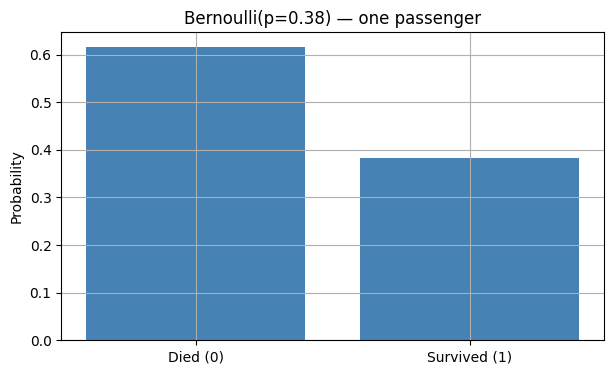

In [ ]:
p_survive = titanic['survived'].mean()
print(f"Empirical survival rate (our Bernoulli p): {p_survive:.3f}")

x = [0, 1]
pmf = stats.bernoulli.pmf(x, p=p_survive)
plt.bar(['Died (0)', 'Survived (1)'], pmf, color='steelblue')
plt.title(f'Bernoulli(p={p_survive:.2f}) — one passenger')
plt.ylabel('Probability')
plt.show()

### Binomial — count of successes in $n$ independent Bernoulli trials

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Example: out of 20 randomly chosen passengers, how many survive?

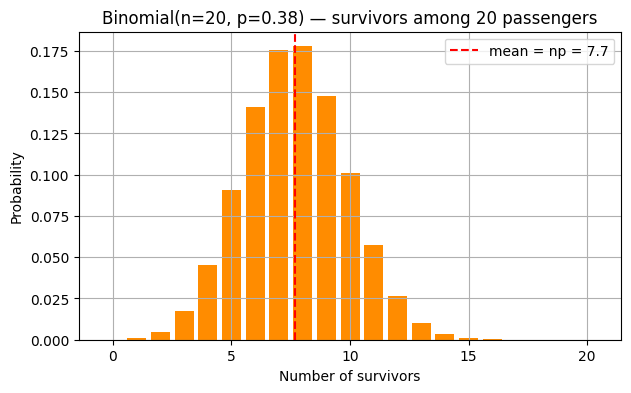

Mean = np = 7.68   Variance = np(1-p) = 4.73


In [ ]:
n = 20
x = np.arange(0, n+1)
pmf = stats.binom.pmf(x, n=n, p=p_survive)

plt.bar(x, pmf, color='darkorange')
plt.axvline(n*p_survive, color='red', linestyle='--', label=f'mean = np = {n*p_survive:.1f}')
plt.title(f'Binomial(n={n}, p={p_survive:.2f}) — survivors among 20 passengers')
plt.xlabel('Number of survivors'); plt.ylabel('Probability'); plt.legend()
plt.show()

print(f"Mean = np = {n*p_survive:.2f}   Variance = np(1-p) = {n*p_survive*(1-p_survive):.2f}")

### Geometric — number of trials until the first success

$$P(X=k) = (1-p)^{k-1} p$$

Example: how many randomly-drawn passengers until we find the first survivor?

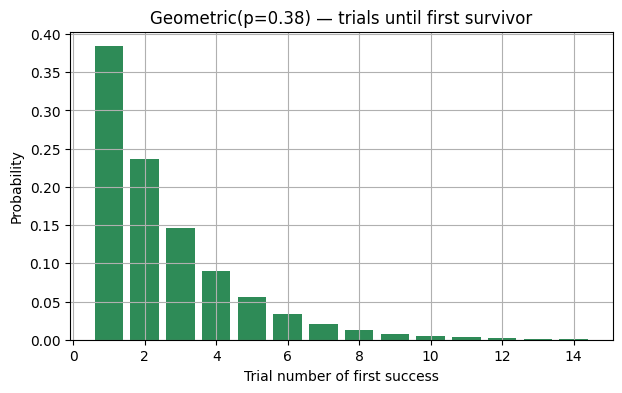

Expected number of trials = 1/p = 2.61


In [ ]:
x = np.arange(1, 15)
pmf = stats.geom.pmf(x, p=p_survive)
plt.bar(x, pmf, color='seagreen')
plt.title(f'Geometric(p={p_survive:.2f}) — trials until first survivor')
plt.xlabel('Trial number of first success'); plt.ylabel('Probability')
plt.show()
print(f"Expected number of trials = 1/p = {1/p_survive:.2f}")

### Poisson — number of rare events in a fixed interval

$$P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

Governed by a single parameter $\lambda$ = the average rate. Classic uses: number of emails per hour, number of typos per page, number of large family groups boarding per minute.

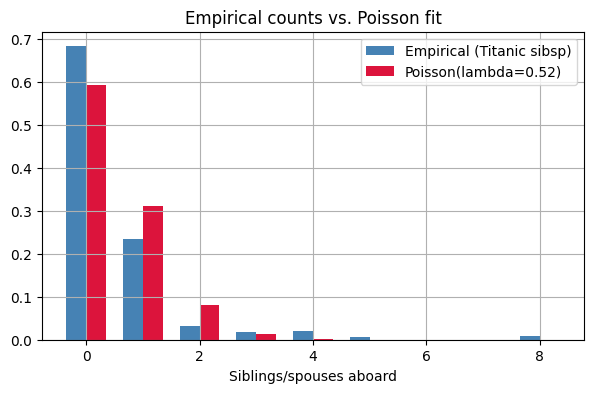

In [ ]:
# Treat siblings/spouses aboard (sibsp) as a Poisson-ish count variable
lam = titanic['sibsp'].mean()
x = np.arange(0, 9)
empirical = titanic['sibsp'].value_counts(normalize=True).reindex(x, fill_value=0)
poisson_pmf = stats.poisson.pmf(x, mu=lam)

width = 0.35
plt.bar(x - width/2, empirical, width, label='Empirical (Titanic sibsp)', color='steelblue')
plt.bar(x + width/2, poisson_pmf, width, label=f'Poisson(lambda={lam:.2f})', color='crimson')
plt.title('Empirical counts vs. Poisson fit')
plt.xlabel('Siblings/spouses aboard'); plt.legend()
plt.show()

The Poisson fit is imperfect here (real sibling counts cluster harder at 0 than a Poisson would), which is itself a useful lesson: **always check a distributional assumption against real data before trusting it.**

---
# Part 2 — Continuous probability distributions

A continuous random variable's **probability density function (PDF)** $f(x)$ doesn't give $P(X=x)$ directly (that's 0 for any single point) — instead, area under the curve between two points gives probability: $P(a \le X \le b) = \int_a^b f(x)\,dx$.

### Uniform — every value in a range equally likely

$$f(x) = \frac{1}{b-a}, \quad a \le x \le b$$

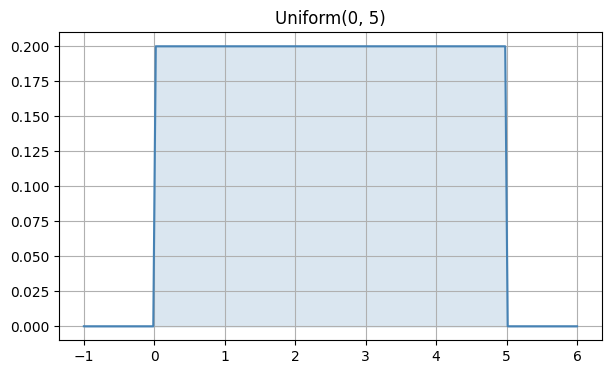

In [ ]:
x = np.linspace(-1, 6, 200)
pdf = stats.uniform.pdf(x, loc=0, scale=5)
plt.plot(x, pdf, color='steelblue'); plt.fill_between(x, pdf, alpha=0.2, color='steelblue')
plt.title('Uniform(0, 5)')
plt.show()

### Normal (Gaussian) — the bell curve

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Fully described by mean $\mu$ and standard deviation $\sigma$. We'll see in Part 6 *why* it appears so often — the Central Limit Theorem.

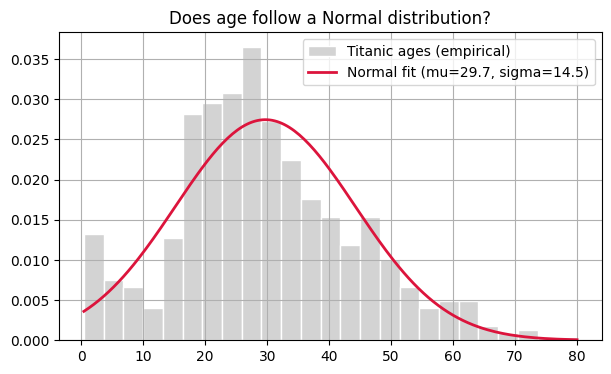

In [ ]:
age = titanic['age'].dropna()
mu, sigma = age.mean(), age.std()

x = np.linspace(age.min(), age.max(), 200)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.hist(age, bins=25, density=True, color='lightgray', edgecolor='white', label='Titanic ages (empirical)')
plt.plot(x, pdf, color='crimson', linewidth=2, label=f'Normal fit (mu={mu:.1f}, sigma={sigma:.1f})')
plt.legend(); plt.title('Does age follow a Normal distribution?')
plt.show()

The fit is only approximate — real age data has a heavier right tail than a true Normal. Distributional fits are approximations, not guarantees.

### Exponential — time between events in a Poisson process

$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0$$

The continuous cousin of the geometric distribution — "waiting time" instead of "waiting count." Memoryless: how long you've already waited tells you nothing about how much longer you'll wait.

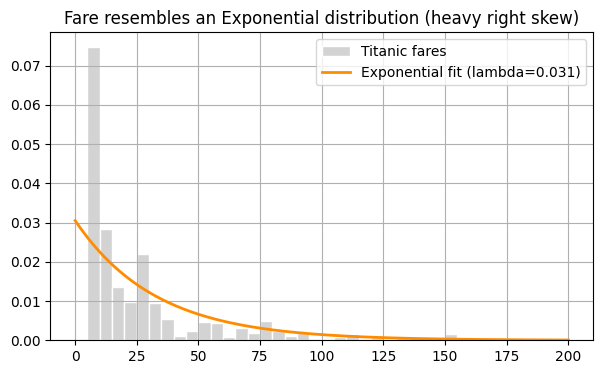

In [ ]:
fare = titanic['fare']
fare_nonzero = fare[fare > 0]
lam_fare = 1 / fare_nonzero.mean()

x = np.linspace(0, 200, 200)
pdf = stats.expon.pdf(x, scale=1/lam_fare)

plt.hist(fare_nonzero, bins=40, density=True, range=(0,200), color='lightgray', edgecolor='white', label='Titanic fares')
plt.plot(x, pdf, color='darkorange', linewidth=2, label=f'Exponential fit (lambda={lam_fare:.3f})')
plt.legend(); plt.title('Fare resembles an Exponential distribution (heavy right skew)')
plt.show()

### Beta — a distribution over probabilities themselves (0 to 1)

$$f(x) \propto x^{\alpha-1}(1-x)^{\beta-1}, \quad 0 \le x \le 1$$

Useful whenever the *quantity itself* is a proportion or probability — e.g. our belief about the true survival rate $p$, before and after seeing data (this connects directly back to Bayes' theorem from the previous course).

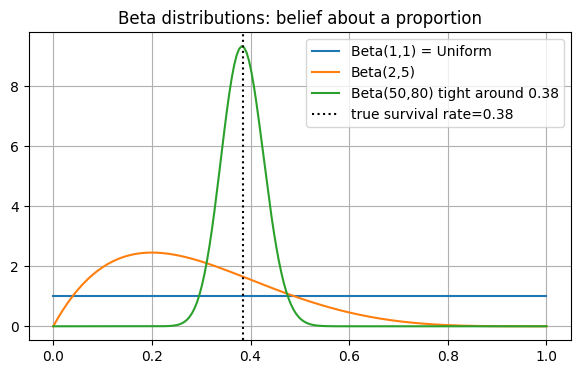

In [ ]:
x = np.linspace(0, 1, 200)
fig, ax = plt.subplots()
for a, b, label in [(1,1,'Beta(1,1) = Uniform'), (2,5,'Beta(2,5)'), (50,80,'Beta(50,80) tight around 0.38')]:
    ax.plot(x, stats.beta.pdf(x, a, b), label=label)
ax.axvline(p_survive, color='black', linestyle=':', label=f'true survival rate={p_survive:.2f}')
ax.legend(); ax.set_title('Beta distributions: belief about a proportion')
plt.show()

---
# Part 3 — PMF, PDF and CDF: three views of one distribution

The **cumulative distribution function** $F(x) = P(X \le x)$ works for both discrete and continuous variables and is often the most useful for answering real questions ("what fraction of passengers were under 30?").

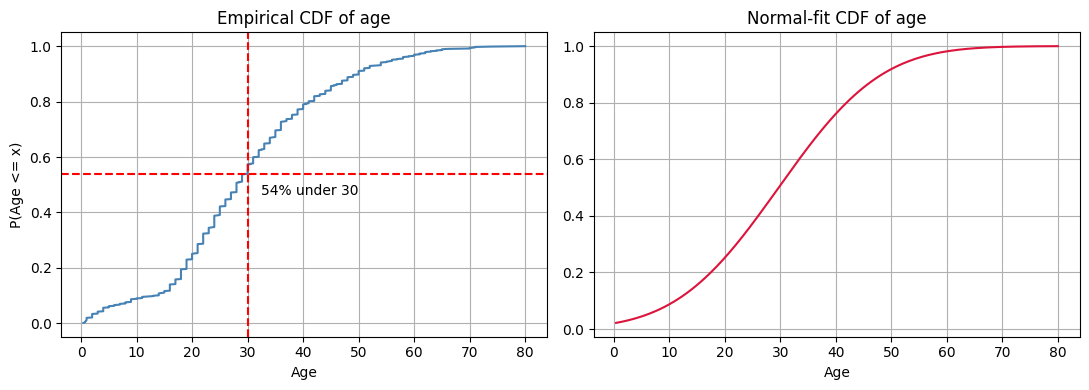

P(Age <= 30) empirically = 0.538


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

# CDF from empirical data
sorted_age = np.sort(age)
cdf_y = np.arange(1, len(sorted_age)+1) / len(sorted_age)
axes[0].plot(sorted_age, cdf_y, color='steelblue')
axes[0].set_title('Empirical CDF of age')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('P(Age <= x)')

# Read off a specific question directly from the CDF
age_30_pct = np.searchsorted(sorted_age, 30) / len(sorted_age)
axes[0].axvline(30, color='red', linestyle='--')
axes[0].axhline(age_30_pct, color='red', linestyle='--')
axes[0].annotate(f'{age_30_pct:.0%} under 30', (30, age_30_pct), textcoords='offset points', xytext=(10,-15))

# CDF of a fitted Normal for comparison
x = np.linspace(age.min(), age.max(), 200)
axes[1].plot(x, stats.norm.cdf(x, mu, sigma), color='crimson')
axes[1].set_title('Normal-fit CDF of age')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()
print(f"P(Age <= 30) empirically = {age_30_pct:.3f}")

---
# Part 4 — Sampling techniques

We rarely observe an entire population — we work with a **sample**. *How* we draw that sample determines whether it fairly represents the population. We'll treat the full Titanic dataset (891 passengers) as our "population" and draw samples from it.

### 4.1 Simple random sampling
Every member of the population has an equal chance of being selected — the baseline, unbiased method.

In [ ]:
population = titanic.copy()
simple_sample = population.sample(n=100, random_state=1)   # without replacement by default

print(f"Population survival rate: {population['survived'].mean():.3f}")
print(f"Sample survival rate:     {simple_sample['survived'].mean():.3f}")

Population survival rate: 0.384
Sample survival rate:     0.390


### 4.2 Sampling with vs. without replacement

- **Without replacement**: each individual can be selected only once (typical for surveys — you don't ask the same person twice)
- **With replacement**: an individual can be selected multiple times (used for bootstrap resampling, Part 7)

In [ ]:
without_repl = population.sample(n=50, replace=False, random_state=1)
with_repl    = population.sample(n=50, replace=True, random_state=1)

print(f"Without replacement — unique passengers selected: {without_repl.index.nunique()} / 50")
print(f"With replacement    — unique passengers selected: {with_repl.index.nunique()} / 50  (some repeats)")

Without replacement — unique passengers selected: 50 / 50
With replacement    — unique passengers selected: 50 / 50  (some repeats)


### 4.3 Stratified sampling

Split the population into homogeneous **strata** (here, passenger class) and sample proportionally from each — guarantees every subgroup is represented in the right proportion, reducing variance versus simple random sampling.

In [ ]:
def stratified_sample(df, strata_col, frac):
    parts = [g.sample(frac=frac, random_state=1) for _, g in df.groupby(strata_col)]
    return pd.concat(parts)

strat_sample = stratified_sample(population, 'class', frac=0.15)

comparison = pd.DataFrame({
    'Population %': population['class'].value_counts(normalize=True),
    'Simple random sample %': simple_sample['class'].value_counts(normalize=True),
    'Stratified sample %': strat_sample['class'].value_counts(normalize=True),
}).round(3)
comparison

,Population %,Simple random sample %,Stratified sample %
class,,,
Third,0.551,0.55,0.552
First,0.242,0.23,0.239
Second,0.207,0.22,0.209


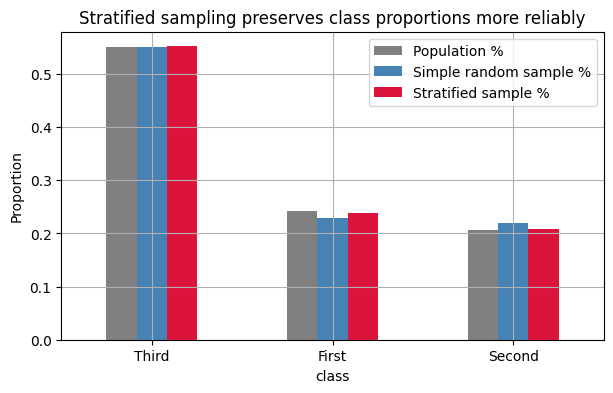

In [ ]:
comparison.plot(kind='bar', figsize=(7,4), color=['gray','steelblue','crimson'])
plt.title('Stratified sampling preserves class proportions more reliably')
plt.ylabel('Proportion'); plt.xticks(rotation=0)
plt.show()

### 4.4 Systematic sampling

Pick every $k$-th individual from a (randomly ordered) list. Simple to implement, and equivalent to simple random sampling as long as there's no hidden periodic pattern in the ordering.

In [ ]:
k = 9   # every 9th passenger -> roughly 100 of 891
shuffled = population.sample(frac=1, random_state=7).reset_index(drop=True)  # randomize order first
systematic_sample = shuffled.iloc[::k]

print(f"Systematic sample size: {len(systematic_sample)}")
print(f"Systematic sample survival rate: {systematic_sample['survived'].mean():.3f}")

Systematic sample size: 99
Systematic sample survival rate: 0.384


### 4.5 Cluster sampling

Split the population into **clusters** (naturally occurring groups), randomly select a *few whole clusters*, and use every member of those clusters. Cheaper when the population is geographically or structurally grouped — but less precise than stratified sampling, since clusters may not be perfectly representative.

In [ ]:
# Treat embarkation port as natural "clusters"
clusters = population['embark_town'].dropna().unique()
chosen_clusters = np.random.choice(clusters, size=2, replace=False)
cluster_sample = population[population['embark_town'].isin(chosen_clusters)]

print(f"Chosen clusters: {chosen_clusters}")
print(f"Cluster sample size: {len(cluster_sample)}")
print(f"Cluster sample survival rate: {cluster_sample['survived'].mean():.3f}")
print(f"(True population rate: {population['survived'].mean():.3f} — cluster sampling can drift further from it)")

Chosen clusters: ['Southampton' 'Cherbourg']
Cluster sample size: 812
Cluster sample survival rate: 0.382
(True population rate: 0.384 — cluster sampling can drift further from it)


### 4.6 Summary of sampling techniques

| Technique | How it works | Best when |
|---|---|---|
| Simple random | Every unit equally likely | No known subgroup structure |
| Stratified | Sample proportionally within known subgroups | Subgroups differ meaningfully, want guaranteed representation |
| Systematic | Every k-th unit from a randomized list | Need a simple, fast method with no periodicity risk |
| Cluster | Randomly pick whole groups, use all members | Population naturally grouped, individual sampling is costly |
| Bootstrap (with replacement) | Resample the *sample itself* many times | Estimating the sampling distribution of a statistic (Part 7) |

---
# Part 5 — Sampling distributions & standard error

If we repeatedly draw samples and compute a statistic (e.g. the mean) each time, that statistic itself has a distribution — the **sampling distribution**. Its spread is measured by the **standard error**:

$$SE = \frac{\sigma}{\sqrt{n}}$$

Larger samples give a *less variable* sample mean — this is the seed of the Central Limit Theorem.

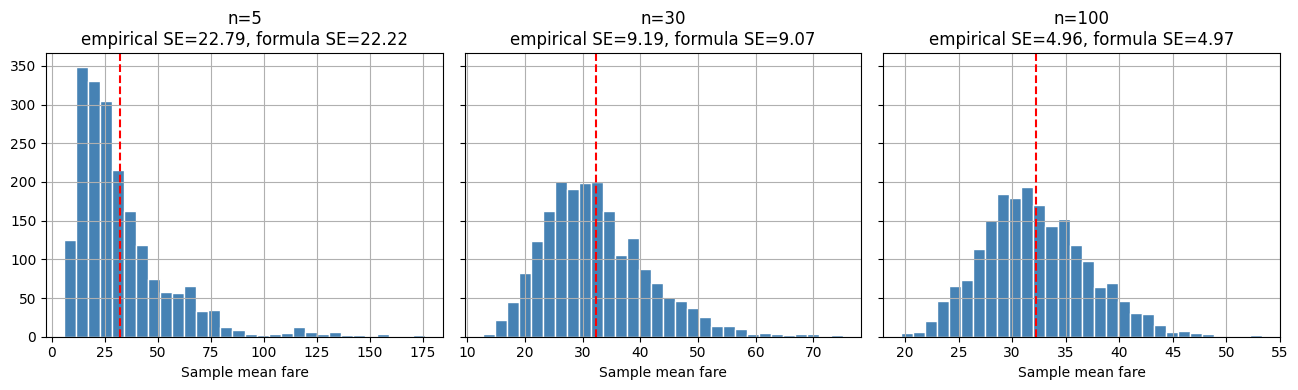

In [ ]:
fare_population = titanic['fare'].dropna()
pop_mean, pop_std = fare_population.mean(), fare_population.std()

sample_sizes = [5, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(13,4), sharey=True)

for ax, n in zip(axes, sample_sizes):
    sample_means = [fare_population.sample(n, replace=True, random_state=i).mean() for i in range(2000)]
    ax.hist(sample_means, bins=30, color='steelblue', edgecolor='white')
    se_empirical = np.std(sample_means)
    se_formula   = pop_std / np.sqrt(n)
    ax.axvline(pop_mean, color='red', linestyle='--')
    ax.set_title(f'n={n}\nempirical SE={se_empirical:.2f}, formula SE={se_formula:.2f}')
    ax.set_xlabel('Sample mean fare')

plt.tight_layout()
plt.show()

As sample size grows, the sampling distribution of the mean gets **narrower** (smaller SE) — bigger samples give more precise estimates, shrinking proportionally to $1/\sqrt{n}$, not $1/n$ (diminishing returns).

---
# Part 6 — The Central Limit Theorem (CLT)

> **If you draw sufficiently large random samples from *any* population with finite variance and compute their means, the distribution of those sample means approaches a Normal distribution — regardless of the shape of the original population.**

$$\bar{X} \sim \text{approximately Normal}\left(\mu, \frac{\sigma^2}{n}\right) \text{ as } n \to \infty$$

This is why the Normal distribution is everywhere in statistics: it's the destination that *averages* converge to, even when individual observations don't look Normal at all.

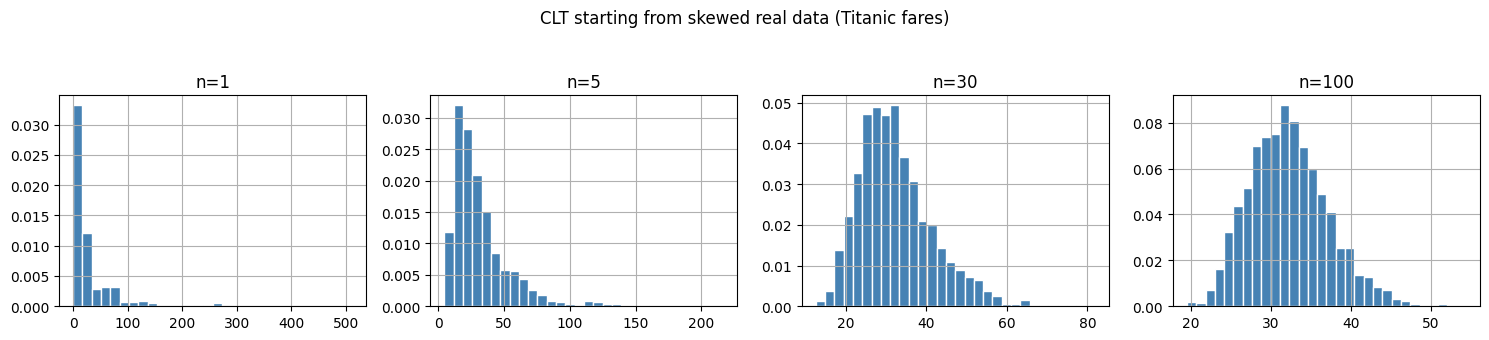

In [ ]:
def clt_demo(population_sampler, title, sample_sizes=(1, 5, 30, 100)):
    fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 3.2))
    for ax, n in zip(axes, sample_sizes):
        means = [population_sampler(n).mean() for _ in range(3000)]
        ax.hist(means, bins=30, density=True, color='steelblue', edgecolor='white')
        ax.set_title(f'n={n}')
    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

# 1. Start from a badly-skewed population: Titanic fares (heavy right skew)
clt_demo(lambda n: fare_population.sample(n, replace=True), "CLT starting from skewed real data (Titanic fares)")

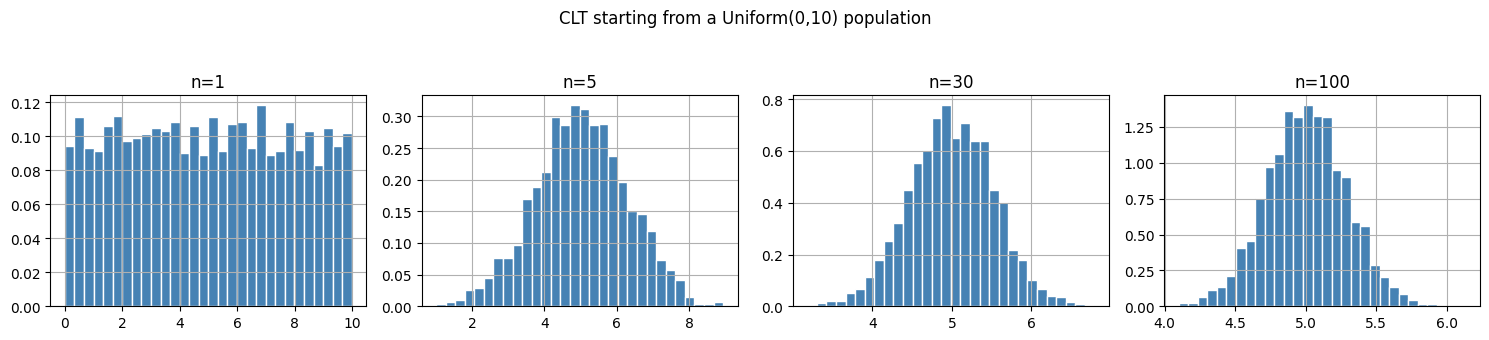

In [ ]:
# 2. Start from a population that isn't even bell-shaped at all: Uniform
clt_demo(lambda n: pd.Series(np.random.uniform(0, 10, n)), "CLT starting from a Uniform(0,10) population")

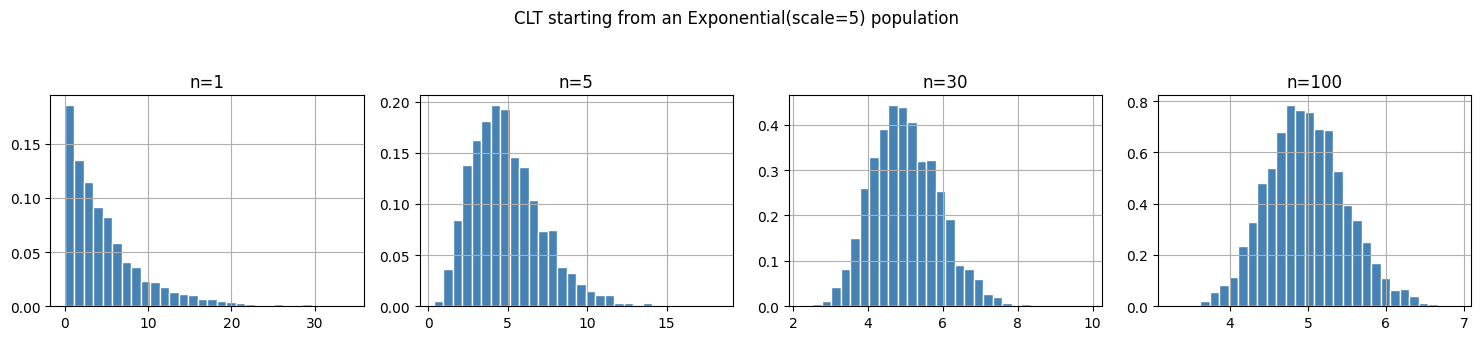

In [ ]:
# 3. Start from an Exponential distribution (also skewed, but a clean parametric case)
clt_demo(lambda n: pd.Series(np.random.exponential(scale=5, size=n)), "CLT starting from an Exponential(scale=5) population")

In every case — no matter how skewed, flat, or oddly shaped the *original* population is — by around $n=30$ the distribution of the **sample mean** already looks close to Normal. This is the CLT in action, and it's what justifies using Normal-based formulas (like confidence intervals) even when raw data isn't Normal.

### From CLT to confidence intervals

Because $\bar{X}$ is approximately Normal, a 95% confidence interval for the population mean is:

$$\bar{x} \pm 1.96 \times \frac{s}{\sqrt{n}}$$

In [ ]:
n = 50
sample = fare_population.sample(n, random_state=3)
x_bar, s = sample.mean(), sample.std(ddof=1)
se = s / np.sqrt(n)
ci_low, ci_high = x_bar - 1.96*se, x_bar + 1.96*se

print(f"Sample mean fare: {x_bar:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"True population mean: {pop_mean:.2f}  -> {'inside' if ci_low <= pop_mean <= ci_high else 'outside'} the interval")

Sample mean fare: 37.43
95% CI: [22.38, 52.48]
True population mean: 32.20  -> inside the interval


In [ ]:
# Confirm the "95%" claim by simulation: what fraction of many such intervals actually contain the true mean?
hits = 0
n_trials = 1000
for i in range(n_trials):
    s = fare_population.sample(n, replace=True, random_state=i)
    xb, sd = s.mean(), s.std(ddof=1)
    se = sd / np.sqrt(n)
    lo, hi = xb - 1.96*se, xb + 1.96*se
    hits += (lo <= pop_mean <= hi)

print(f"Coverage: {hits}/{n_trials} = {hits/n_trials:.3f}  (should be close to 0.95)")

Coverage: 900/1000 = 0.900  (should be close to 0.95)


---
# Part 7 — Application: bootstrap confidence intervals

The **bootstrap** sidesteps needing a formula (or even a CLT approximation) at all: resample your *observed sample itself*, with replacement, many times, and use the spread of the resulting statistic directly as the sampling distribution. Especially useful for statistics (like the median, or skewness) with no simple standard-error formula.

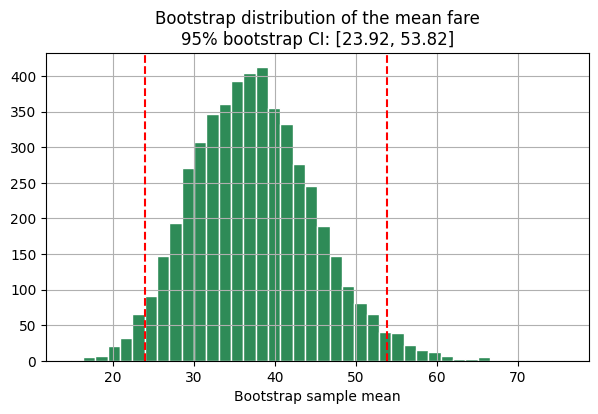

In [ ]:
observed_sample = fare_population.sample(50, random_state=3)   # imagine this is all the data we collected

n_boot = 5000
boot_means = np.array([observed_sample.sample(len(observed_sample), replace=True).mean()
                        for _ in range(n_boot)])

boot_ci_low, boot_ci_high = np.percentile(boot_means, [2.5, 97.5])

plt.hist(boot_means, bins=40, color='seagreen', edgecolor='white')
plt.axvline(boot_ci_low, color='red', linestyle='--')
plt.axvline(boot_ci_high, color='red', linestyle='--')
plt.title(f'Bootstrap distribution of the mean fare\n95% bootstrap CI: [{boot_ci_low:.2f}, {boot_ci_high:.2f}]')
plt.xlabel('Bootstrap sample mean')
plt.show()

In [ ]:
# Bootstrap also works for statistics with no clean formula, e.g. the MEDIAN
boot_medians = np.array([observed_sample.sample(len(observed_sample), replace=True).median()
                          for _ in range(n_boot)])
med_ci_low, med_ci_high = np.percentile(boot_medians, [2.5, 97.5])

print(f"Observed sample median: {observed_sample.median():.2f}")
print(f"95% bootstrap CI for the median: [{med_ci_low:.2f}, {med_ci_high:.2f}]")

Observed sample median: 14.87
95% bootstrap CI for the median: [11.50, 22.02]


---
# Part 8 — Exercises

1. **Distributions**: Fit a Poisson distribution to the `parch` (parents/children aboard) column the way we did for `sibsp`. Plot empirical vs. fitted PMF — is the fit better or worse?
2. **Sampling**: Draw a stratified sample by `sex` instead of `class`. Compare the survival rate in the stratified sample vs. a simple random sample of the same size — which is closer to the true population rate, and is that a fluke or expected?
3. **Sampling**: Implement cluster sampling using `deck` instead of `embark_town`. What issue do you run into (hint: check for missing values), and how would you handle it?
4. **CLT**: Rerun the `clt_demo` starting from a **Bernoulli(p=0.1)** population (highly skewed, only two possible values). At what sample size does the sample-mean distribution start looking Normal?
5. **Confidence intervals**: Compute a 95% CI for mean `age` (not `fare`) using both the formula-based method (Part 6) and the bootstrap method (Part 7). How close are they?
6. **Challenge**: The formula-based CI coverage simulation used $n=50$. Repeat it with $n=5$. Does coverage still land near 95%? What does that tell you about how large $n$ needs to be for the CLT approximation to be trustworthy?
